### Clustering Customer Behavior Based on E-commerce Event Data

In a modern e-commerce platform, understanding customer behavior is critical for optimizing user experience and increasing sales. The provided dataset contains information about user interactions with various products on the platform, including event types, product categories, brands, prices, and user sessions.
This is an unsupervised machine learning problem aimed at uncovering hidden patterns in user behavior to group similar users or actions. These insights could assist in personalizing user experiences, targeting advertisements, or improving product recommendations.


#### Data Loading

fetching the name sof the tables present in the database

In [1]:
import sqlite3
# Connect to the database
conn = sqlite3.connect("clustering.db")
cursor = conn.cursor()

# Query to list all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# Fetch and print the results
tables = cursor.fetchall()
print("Tables in database:", tables)

conn.close()

Tables in database: [('tripadvisor_reviews',), ('supermarket_data',), ('ecommerce_behavior',), ('online_retail_customers',), ('amazon_book_reviews',)]


In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("clustering.db")

# This returns a DataFrame of all table names
df_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(df_tables)

conn.close()

                      name
0      tripadvisor_reviews
1         supermarket_data
2       ecommerce_behavior
3  online_retail_customers
4      amazon_book_reviews


In [3]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("clustering.db")
df = pd.read_sql("SELECT * FROM ecommerce_behavior", conn)
conn.close()

In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-04-01 00:00:00 UTC,view,1201465,2232732101407408685,apparel.shoes.slipons,samsung,230.38,568984877,e2456cef-2d4f-42b9-a53a-8893cb0c6851
1,2020-04-01 00:00:01 UTC,view,1307156,2053013554658804075,electronics.audio.headphone,apple,1352.67,514955500,38f43134-de83-4710-ae0a-326677d292c6
2,2020-04-01 00:00:01 UTC,view,1480477,2053013563835941749,appliances.kitchen.refrigerators,apple,1184.05,633645770,16aba270-b3c2-4b23-be0a-b7c80bc9da9e
3,2020-04-01 00:00:02 UTC,view,1307050,2053013554658804075,electronics.audio.headphone,apple,1724.34,564933778,05b443bd-e68a-4d72-b971-80bd31109cb8
4,2020-04-01 00:00:03 UTC,view,9500109,2232732104175649385,apparel.scarf,defender,25.05,530206135,e3c1fb4b-0a7e-457d-a0cf-5d1479e9aafc


In [5]:
df.shape

(1000000, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1000000 non-null  object 
 1   event_type     1000000 non-null  object 
 2   product_id     1000000 non-null  int64  
 3   category_id    1000000 non-null  int64  
 4   category_code  915317 non-null   object 
 5   brand          895048 non-null   object 
 6   price          1000000 non-null  float64
 7   user_id        1000000 non-null  int64  
 8   user_session   999994 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 68.7+ MB


In [7]:
df.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code     84683
brand            104952
price                 0
user_id               0
user_session          6
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(3197)

In [9]:
df=df.drop_duplicates()

In [10]:
df.shape

(996803, 9)

In [11]:
df['event_time']=pd.to_datetime(df['event_time'])

In [12]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-04-01 00:00:00+00:00,view,1201465,2232732101407408685,apparel.shoes.slipons,samsung,230.38,568984877,e2456cef-2d4f-42b9-a53a-8893cb0c6851
1,2020-04-01 00:00:01+00:00,view,1307156,2053013554658804075,electronics.audio.headphone,apple,1352.67,514955500,38f43134-de83-4710-ae0a-326677d292c6
2,2020-04-01 00:00:01+00:00,view,1480477,2053013563835941749,appliances.kitchen.refrigerators,apple,1184.05,633645770,16aba270-b3c2-4b23-be0a-b7c80bc9da9e
3,2020-04-01 00:00:02+00:00,view,1307050,2053013554658804075,electronics.audio.headphone,apple,1724.34,564933778,05b443bd-e68a-4d72-b971-80bd31109cb8
4,2020-04-01 00:00:03+00:00,view,9500109,2232732104175649385,apparel.scarf,defender,25.05,530206135,e3c1fb4b-0a7e-457d-a0cf-5d1479e9aafc


In [13]:
df.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code     84453
brand            104792
price                 0
user_id               0
user_session          6
dtype: int64

In [14]:
(df.isnull().sum()/len(df))*100

event_time        0.000000
event_type        0.000000
product_id        0.000000
category_id       0.000000
category_code     8.472386
brand            10.512809
price             0.000000
user_id           0.000000
user_session      0.000602
dtype: float64

##### Observation
- user_session is quite small missing value -> drop
- category_code and brand are still huge 

##### Separating numerical and categorical data

In [15]:
num_cols=df.select_dtypes(exclude=['object']).columns.to_list()
cat_cols=df.select_dtypes(include=['object']).columns.to_list()

In [16]:
num_cols

['event_time', 'product_id', 'category_id', 'price', 'user_id']

In [17]:
cat_cols

['event_type', 'category_code', 'brand', 'user_session']

In [18]:
df[cat_cols].nunique()

event_type            3
category_code       136
brand              2921
user_session     182715
dtype: int64

##### Obserations:
- high cardinality in all except event_type hence missing cannot be filled with mode here

##### EDA on categorical columns

In [19]:
for i in cat_cols:
    print(df[i].value_counts())
    print("-"*50)

event_type
view        917792
cart         58792
purchase     20219
Name: count, dtype: int64
--------------------------------------------------
category_code
construction.tools.light               239660
electronics.audio.headphone            143351
appliances.personal.massager            37221
appliances.kitchen.refrigerators        34112
sport.bicycle                           30059
                                        ...  
computers.components.hdd                   11
appliances.kitchen.steam_cooker             7
appliances.environment.water_heater         4
appliances.kitchen.microwave                4
appliances.kitchen.coffee_machine           4
Name: count, Length: 136, dtype: int64
--------------------------------------------------
brand
samsung        136183
apple           63378
xiaomi          47408
acer            41506
asus            40625
                ...  
chaod               1
siku                1
withings            1
boomtrix            1
spaquatoria        

##### Observations:
- event_type has all the valid events with view >> cart>> purchase >> this imples most user are not converting
- category_code - class imbalance with few rare categories too
- brand - class imbalance with few rare categories too
- user_session- class imbalance with few rare categories too

Due to high cardinality + imbalance → unknown better for filling missing values of both brands and category_code

In [20]:
#filling missing values with unknown 
for i in ['category_code', 'brand']:
    df[i]=df[i].fillna('unknown')
#dropping user_session
df=df.dropna(subset=['user_session'])

In [21]:
df.isnull().sum()

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64

##### EDA on numerical columns
- price is the only continuous numeric variables so we will evaluate this only

In [22]:
df.price.describe()

count    996797.000000
mean        311.928101
std         369.210757
min           0.000000
25%          69.240000
50%         188.160000
75%         398.720000
max        2574.070000
Name: price, dtype: float64

Price = 0 is not a valid transaction value

In [23]:
df[df['price']<=0].shape

(1773, 9)

In [24]:
(df[df['price']<=0].shape[0]/(len(df))*100)

0.17786971670259843

In [25]:
df.shape

(996797, 9)

In [26]:
#removing price zero
df=df[df['price']>0]

In [27]:
df.shape

(995024, 9)

In [28]:
df.price.describe()

count    995024.000000
mean        312.483915
std         369.304479
min           0.770000
25%          69.470000
50%         190.220000
75%         398.720000
max        2574.070000
Name: price, dtype: float64

<Axes: >

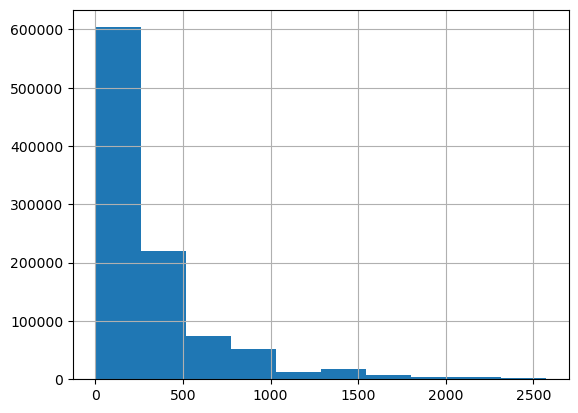

In [29]:
df.price.hist()

##### observation
- Few high prices could be luxury product
- Pull centroids toward them
- Dominate cluster formation
- hence later log function can be applied

### Feature Engineering
- Following to be added:
- total_event() -> Overall activity, Engagement volume, Helps scale-normalize users, Identify power users
- total_view() -> Base activity signal, Browsing intensity, Separates low vs high engagement users, Retarget high viewers with ads
- total_cart -> Mid-funnel behavior, Purchase intent (stronger than views), Helps identify intent clusters, Push reminders / offers
- total_purchase -> Final conversion signal, Actual buyers, Separates revenue-driving users, Loyalty programs
- avg_price -> Monetary behavior, Cheap vs premium shoppers, Splits budget vs luxury segments, Personalized pricing /recommendations
- unique_category -> Exploration behavior, Focused vs exploratory users, Distinguishes niche vs browsing users, Recommend similar vs diverse products
- unique_brand -> Brand loyalty/diversity, Loyal vs variety-seeking users, Adds behavioral depth, Brand-based targeting
- total_session -> Visit frequency, Repeat vs one-time users, Weak (low variance in your data), May drop or use for retention campaigns
- purchase_rate -> Conversion efficiency, Buyer vs browser, VERY strong feature, Identify high-conversion users
- cart_rate, Funnel progression, Interest level, Helps refine intent clusters, Improve product page UX
- cart_to_purchase_ratio -> Cart abandonment, Drop-off behavior, Identifies friction users, Send cart recovery emails
- recency -> User latest activity, active or dormant user

#### Addding total_events, total_cart, total_view, total_purchase

In [30]:
df.user_id.value_counts()

user_id
635214021    1811
597644399    1549
602971000     596
568790544     449
613028319     401
             ... 
514980633       1
512953328       1
635400017       1
590816883       1
633071343       1
Name: count, Length: 146386, dtype: int64

In [31]:
df['user_id'].nunique()

146386

In [32]:
df.user_session.value_counts()

user_session
3783af17-7bfd-4d74-9519-cb34a990fcdc    1811
488b3a63-d91e-4739-a963-7af743f03d54    1549
3e93b6ee-4083-4dce-9944-c605a57a0d86     449
0d1faf64-a3aa-4b30-bd34-d76b7ae5ba8f     401
e79a3a91-4f37-4895-999c-576a0504d469     384
                                        ... 
7619507e-063b-4c33-b830-4a7f081684e0       1
a4d7c601-b1f2-44e2-b6e4-3da694f35da7       1
508f7c44-1502-4dfb-bb1c-ee7b9abad933       1
6126330c-fd6b-4b17-856d-0e70bd218480       1
61335de4-512b-4964-aa6f-d43c364e74a3       1
Name: count, Length: 182643, dtype: int64

In [33]:
df['user_session'].nunique()

182643

We will user user_id as the grouping basis and the above was to check the variance and class

#### Method1

group -> size -> to_frame -> unstack -> merge

In [34]:
#Group first → then derive all features in one place
user_grp=df.groupby('user_id')

In [35]:
#counting the no of 
user_grp.size()

user_id
104655840     1
128968633    18
176250879     3
178539771     1
208005640     4
             ..
635399958     2
635399996     1
635400017     1
635400078     2
635400080     1
Length: 146386, dtype: int64

In [36]:
user_df = user_grp.size().to_frame('total_events')
user_df.head()

,total_events
user_id,
104655840,1
128968633,18
176250879,3
178539771,1
208005640,4


In [37]:
event_counts = df.groupby(['user_id', 'event_type']).size().unstack(fill_value=0)
event_counts.head()

event_type,cart,purchase,view
user_id,,,
104655840,0,0,1
128968633,0,0,18
176250879,0,0,3
178539771,0,0,1
208005640,0,0,4


In [38]:
user_df = user_df.join(event_counts)
user_df.head()

,total_events,cart,purchase,view
user_id,,,,
104655840,1,0,0,1
128968633,18,0,0,18
176250879,3,0,0,3
178539771,1,0,0,1
208005640,4,0,0,4


#### Method2

group + unstack

In [39]:
user_df1=df.groupby(['user_id', 'event_type']).size().unstack(fill_value=0)
user_df1.head()

event_type,cart,purchase,view
user_id,,,
104655840,0,0,1
128968633,0,0,18
176250879,0,0,3
178539771,0,0,1
208005640,0,0,4


In [40]:
user_df1=user_df1.rename(columns={'cart':'total_cart', 'purchase':'total_purchase', 'view':'total_view'})
user_df1.head()

event_type,total_cart,total_purchase,total_view
user_id,,,
104655840,0,0,1
128968633,0,0,18
176250879,0,0,3
178539771,0,0,1
208005640,0,0,4


#### Method 3

cross tab -> wide format

In [41]:
user_df2=pd.crosstab(df['user_id'], df['event_type'])
user_df2.head()

event_type,cart,purchase,view
user_id,,,
104655840,0,0,1
128968633,0,0,18
176250879,0,0,3
178539771,0,0,1
208005640,0,0,4


In [42]:
user_df2=user_df2.rename(columns={'cart':'total_cart', 'purchase':'total_purchase', 'view':'total_view'})
user_df2.head()

event_type,total_cart,total_purchase,total_view
user_id,,,
104655840,0,0,1
128968633,0,0,18
176250879,0,0,3
178539771,0,0,1
208005640,0,0,4


#### Adding total_events

In [43]:
cols = ['total_cart', 'total_purchase', 'total_view']
user_df2['total_events'] = user_df2[cols].sum(axis=1)
user_df2.head()

event_type,total_cart,total_purchase,total_view,total_events
user_id,,,,
104655840,0,0,1,1
128968633,0,0,18,18
176250879,0,0,3,3
178539771,0,0,1,1
208005640,0,0,4,4


Validating the transition has covered all the events correctly

In [44]:
user_df2['total_events'].sum()==len(df)

np.True_

#### avg_price, total_session, unique_brand, unique_category

In [45]:
#creating a series for each
df_price = df.groupby('user_id')['price'].mean()
df_session=df.groupby('user_id')['user_session'].nunique()
df_brand=df.groupby('user_id')['brand'].nunique()
df_cat=df.groupby('user_id')['category_code'].nunique()

In [46]:
df_price.head()

user_id
104655840      9.910000
128968633    195.326111
176250879    420.800000
178539771    566.270000
208005640    281.057500
Name: price, dtype: float64

In [47]:
df_session.head()

user_id
104655840    1
128968633    1
176250879    1
178539771    1
208005640    1
Name: user_session, dtype: int64

In [48]:
df_brand.head()

user_id
104655840    1
128968633    5
176250879    1
178539771    1
208005640    3
Name: brand, dtype: int64

In [49]:
df_cat.head()

user_id
104655840    1
128968633    3
176250879    1
178539771    1
208005640    1
Name: category_code, dtype: int64

In [50]:
#Rename each series
df_session = df_session.rename('total_session')
df_price   = df_price.rename('avg_price')
df_cat     = df_cat.rename('unique_category')
df_brand   = df_brand.rename('unique_brand')

In [51]:
#joining to the main user_df2
user_df2 = user_df2.join([df_session, df_price, df_cat, df_brand])

In [52]:
user_df2.head()

,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand
user_id,,,,,,,,
104655840,0,0,1,1,1,9.910000,1,1
128968633,0,0,18,18,1,195.326111,3,5
176250879,0,0,3,3,1,420.800000,1,1
178539771,0,0,1,1,1,566.270000,1,1
208005640,0,0,4,4,1,281.057500,1,3


#### purchase_rate and cart_rate
- distinguishes buyers vs browsers
- purchase_rate = total_purchase / total_events
- cart_rate = total_cart / total_events

In [53]:
user_df2['purchase_rate']=user_df2['total_purchase']/user_df2['total_events']

In [54]:
user_df2['cart_rate'] = user_df2['total_cart'] / user_df2['total_events']

#### cart_to_purchase_ratio
- ratio = total_purchase / total_cart
- identifies cart abandoners
-  Handle divide by 0
- 0 / 0 → NaN so use fillna 

In [55]:
import numpy as np

user_df2['cart_to_purchase_ratio'] = np.where(
    user_df2['total_cart'] == 0,
    0,
    user_df2['total_purchase'] / user_df2['total_cart']
)

In [56]:
user_df2.head()

,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand,purchase_rate,cart_rate,cart_to_purchase_ratio
user_id,,,,,,,,,,,
104655840,0,0,1,1,1,9.910000,1,1,0.0,0.0,0.0
128968633,0,0,18,18,1,195.326111,3,5,0.0,0.0,0.0
176250879,0,0,3,3,1,420.800000,1,1,0.0,0.0,0.0
178539771,0,0,1,1,1,566.270000,1,1,0.0,0.0,0.0
208005640,0,0,4,4,1,281.057500,1,3,0.0,0.0,0.0


#### avg_events_per_session
- avg_events_per_session = total_events / total_session
- captures the engagement depth

In [57]:
user_df2.total_session.value_counts(normalize=True)

total_session
1      0.841556
2      0.110420
3      0.029286
4      0.009659
5      0.004304
6      0.002254
7      0.000902
8      0.000567
9      0.000335
10     0.000232
11     0.000164
12     0.000109
13     0.000061
14     0.000034
15     0.000027
18     0.000014
16     0.000014
21     0.000014
24     0.000007
22     0.000007
27     0.000007
34     0.000007
25     0.000007
17     0.000007
154    0.000007
Name: proportion, dtype: float64

In [58]:
df.groupby('user_id')['user_session'].nunique().describe()

count    146386.000000
mean          1.247742
std           0.851583
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         154.000000
Name: user_session, dtype: float64

Since session mostly = 1 then it not provide the exact engaement per user. Hence, we will avoid it

#### recency
- recency = (max_date - user_last_activity)
- distinguishes: active users and dormant users

In [59]:
#get reference date the max date in the whole dataframe 
max_date = df['event_time'].max()
max_date

Timestamp('2020-04-01 14:08:27+0000', tz='UTC')

In [60]:
#get last activity per user
df_last=df.groupby('user_id')['event_time'].max()

In [61]:
df_last.head()

user_id
104655840   2020-04-01 13:20:03+00:00
128968633   2020-04-01 12:51:01+00:00
176250879   2020-04-01 04:30:01+00:00
178539771   2020-04-01 13:03:34+00:00
208005640   2020-04-01 06:09:22+00:00
Name: event_time, dtype: datetime64[ns, UTC]

In [62]:
#compute recency
recency=(max_date-df_last).dt.days

In [63]:
recency.head()

user_id
104655840    0
128968633    0
176250879    0
178539771    0
208005640    0
Name: event_time, dtype: int64

In [64]:
user_df2=user_df2.join(recency.rename('recency'))

In [65]:
user_df2.head()

,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand,purchase_rate,cart_rate,cart_to_purchase_ratio,recency
user_id,,,,,,,,,,,,
104655840,0,0,1,1,1,9.910000,1,1,0.0,0.0,0.0,0
128968633,0,0,18,18,1,195.326111,3,5,0.0,0.0,0.0,0
176250879,0,0,3,3,1,420.800000,1,1,0.0,0.0,0.0,0
178539771,0,0,1,1,1,566.270000,1,1,0.0,0.0,0.0,0
208005640,0,0,4,4,1,281.057500,1,3,0.0,0.0,0.0,0


In [66]:
user_df2.recency.value_counts()

recency
0    146386
Name: count, dtype: int64

We observe that there is only one value 0 in the recency so this implies
- all events are on same date → no variation
- No variance → no clustering value
- Adds noise, not signal
- we could have tried the following in the beginning of the EDA phase on the event_time to infer if we needed to calculate and add recency

In [67]:
df['event_time'].max()

Timestamp('2020-04-01 14:08:27+0000', tz='UTC')

In [68]:
df['event_time'].min()

Timestamp('2020-04-01 00:00:00+0000', tz='UTC')

Since both the dates are the same, we should have inferred to drop the recency idea at the beginning itself

In [69]:
user_df2.size

1756632

In [70]:
user_df2=user_df2.drop('recency', axis=1)

In [71]:
user_df2.head()

,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand,purchase_rate,cart_rate,cart_to_purchase_ratio
user_id,,,,,,,,,,,
104655840,0,0,1,1,1,9.910000,1,1,0.0,0.0,0.0
128968633,0,0,18,18,1,195.326111,3,5,0.0,0.0,0.0
176250879,0,0,3,3,1,420.800000,1,1,0.0,0.0,0.0
178539771,0,0,1,1,1,566.270000,1,1,0.0,0.0,0.0
208005640,0,0,4,4,1,281.057500,1,3,0.0,0.0,0.0


In [72]:
user_df2.size

1610246

In [73]:
user_df2.columns.name = None

In [74]:
user_df2.head()

,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand,purchase_rate,cart_rate,cart_to_purchase_ratio
user_id,,,,,,,,,,,
104655840,0,0,1,1,1,9.910000,1,1,0.0,0.0,0.0
128968633,0,0,18,18,1,195.326111,3,5,0.0,0.0,0.0
176250879,0,0,3,3,1,420.800000,1,1,0.0,0.0,0.0
178539771,0,0,1,1,1,566.270000,1,1,0.0,0.0,0.0
208005640,0,0,4,4,1,281.057500,1,3,0.0,0.0,0.0


In [75]:
user_df2 = user_df2.reset_index()

In [76]:
user_df2.head()

,user_id,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand,purchase_rate,cart_rate,cart_to_purchase_ratio
0,104655840,0,0,1,1,1,9.910000,1,1,0.0,0.0,0.0
1,128968633,0,0,18,18,1,195.326111,3,5,0.0,0.0,0.0
2,176250879,0,0,3,3,1,420.800000,1,1,0.0,0.0,0.0
3,178539771,0,0,1,1,1,566.270000,1,1,0.0,0.0,0.0
4,208005640,0,0,4,4,1,281.057500,1,3,0.0,0.0,0.0


#### Reading DF and EDA post feature engineering 

In [77]:
user_df2.shape

(146386, 12)

In [78]:
user_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146386 entries, 0 to 146385
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   user_id                 146386 non-null  int64  
 1   total_cart              146386 non-null  int64  
 2   total_purchase          146386 non-null  int64  
 3   total_view              146386 non-null  int64  
 4   total_events            146386 non-null  int64  
 5   total_session           146386 non-null  int64  
 6   avg_price               146386 non-null  float64
 7   unique_category         146386 non-null  int64  
 8   unique_brand            146386 non-null  int64  
 9   purchase_rate           146386 non-null  float64
 10  cart_rate               146386 non-null  float64
 11  cart_to_purchase_ratio  146386 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 13.4 MB


no nulls and no object data types found 

In [79]:
user_df2.describe()

,user_id,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand,purchase_rate,cart_rate,cart_to_purchase_ratio
count,1.463860e+05,146386.000000,146386.000000,146386.000000,146386.000000,146386.000000,146386.000000,146386.000000,146386.000000,146386.000000,146386.000000,146386.000000
mean,5.782117e+08,0.401377,0.138121,6.257764,6.797262,1.247742,334.288164,1.452687,2.166888,0.015058,0.041975,0.070846
std,4.587039e+07,1.331248,0.566199,12.310780,12.829446,0.851583,375.727147,1.189199,2.209051,0.054280,0.109303,0.235015
min,1.046558e+08,0.000000,0.000000,0.000000,1.000000,1.000000,0.770000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,5.323349e+08,0.000000,0.000000,1.000000,1.000000,1.000000,79.985625,1.000000,1.000000,0.000000,0.000000,0.000000
50%,5.814642e+08,0.000000,0.000000,3.000000,3.000000,1.000000,204.972286,1.000000,1.000000,0.000000,0.000000,0.000000
75%,6.256551e+08,0.000000,0.000000,7.000000,8.000000,1.000000,426.750000,1.000000,3.000000,0.000000,0.000000,0.000000
max,6.354001e+08,77.000000,57.000000,1811.000000,1811.000000,154.000000,2574.070000,42.000000,81.000000,1.000000,1.000000,2.000000


Observations:
- total_cart, total_purchase: Majority users are non-converting, with 75% not reaching cart or purchase stage
- total_views: Max high -> few heavy users are engaged.  max>> 75 percential -> Long tail distribution highly skewed
- total_session: Low sessions reflect dataset limitation, not true user loyalty since it's one day data
- avg_price: mean >> median and , max >> 75th percentile-> Right-skewed distribution → few high-value purchases dominate
- unique_category: 75th percentile people explored one cat-> Most users are focused → not exploratory
- unique_brand: Strong indication of brand stickiness
- purchase_rate and cart_rate:mean ≈ 0.015 -> Only ~1.5% of events lead to purchase and mean ≈ 0.04 -> Only ~4% reach cart -> massive funnel drop huge scope for optimization and business

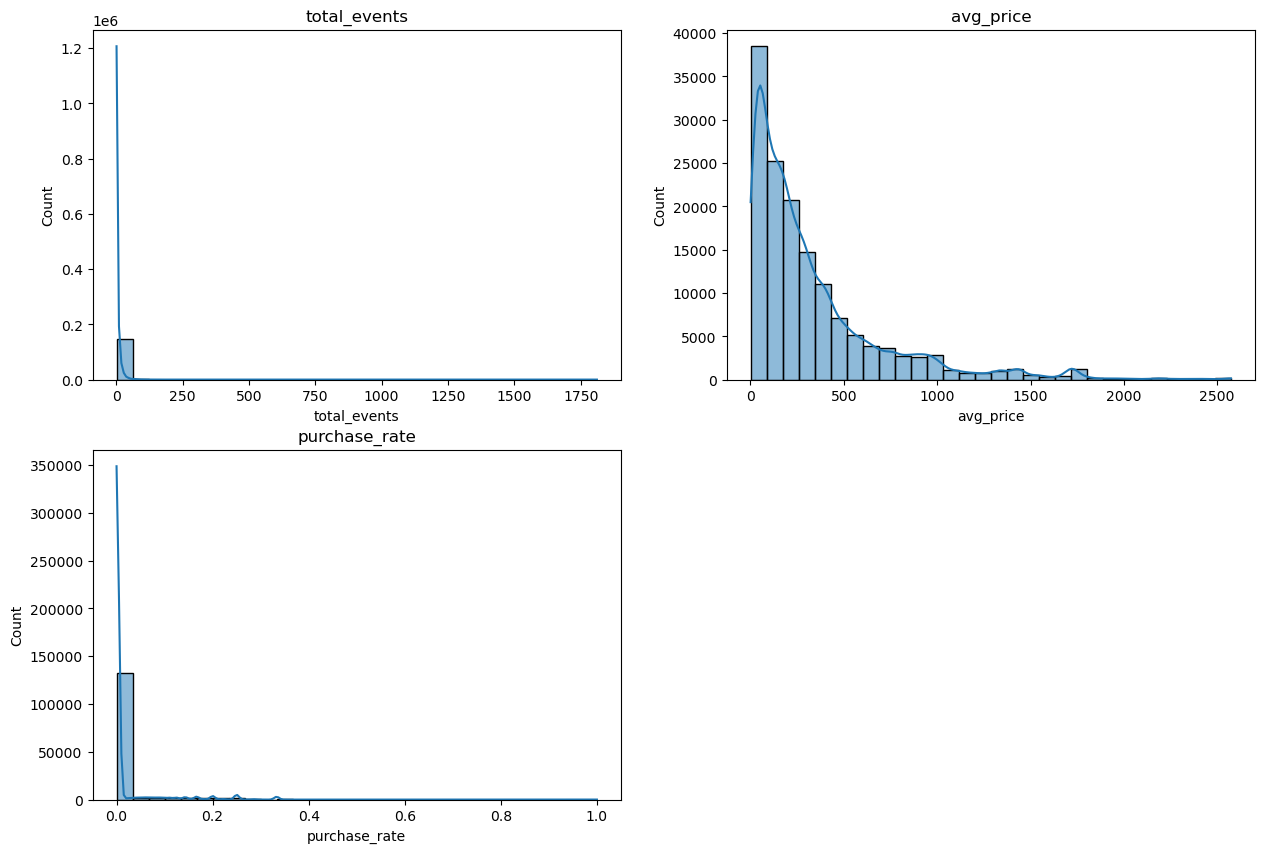

In [80]:
import seaborn as sns 
import matplotlib.pyplot as plt

cols=['total_events','avg_price','purchase_rate']
plt.figure(figsize=(15,10))
for i, col in enumerate(cols):
    plt.subplot(2,2,i+1)
    sns.histplot(data=user_df2, x=col, bins=30, kde=True)
    plt.title(col)
plt.show()

### Applying log transformation 
- log transformatin fixes distribution while scaling fixes feature importance

In [81]:
#checking which all columns needs log transformation 
for i in user_df2.columns.to_list():
    print(user_df2[i].value_counts())
    print("-"*50)

user_id
635400080    1
104655840    1
635399723    1
635399709    1
635399704    1
            ..
236295832    1
223040803    1
208005640    1
178539771    1
176250879    1
Name: count, Length: 146386, dtype: int64
--------------------------------------------------
total_cart
0     119789
1      13911
2       5893
3       2907
4       1489
5        850
6        485
7        311
8        202
9        126
10        88
11        70
12        54
13        44
14        28
16        19
17        19
15        17
18        13
20        12
21        11
19         8
24         6
26         5
28         5
23         4
22         4
36         2
53         2
25         2
27         2
77         1
57         1
39         1
49         1
69         1
35         1
62         1
30         1
Name: count, dtype: int64
--------------------------------------------------
total_purchase
0     131882
1      11286
2       2114
3        578
4        265
5        109
6         45
7         29
8         23
9      

Observation:
- clustering cares about distribution + outliers and rare extremes can be observed in total_cart, total_purchase, total_view, total_events	- - -
- total_session has low variance better to avoid log transformation
- avg_price right-skewed → log transform is necessary
- unique_category and unique_brand are right-skewed, hecne log can be applied

In [82]:
col_transform=user_df2.columns.to_list()
col_transform

['user_id',
 'total_cart',
 'total_purchase',
 'total_view',
 'total_events',
 'total_session',
 'avg_price',
 'unique_category',
 'unique_brand',
 'purchase_rate',
 'cart_rate',
 'cart_to_purchase_ratio']

In [83]:
col_transform=[x for x in col_transform if x not in ['user_id', 'purchase_rate', 'cart_rate', 'cart_to_purchase_ratio','total_session']]
col_transform

['total_cart',
 'total_purchase',
 'total_view',
 'total_events',
 'avg_price',
 'unique_category',
 'unique_brand']

In [84]:
user_df2[col_transform] = np.log1p(user_df2[col_transform])

In [85]:
user_df2.head()

,user_id,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand,purchase_rate,cart_rate,cart_to_purchase_ratio
0,104655840,0.0,0.0,0.693147,0.693147,1,2.389680,0.693147,0.693147,0.0,0.0,0.0
1,128968633,0.0,0.0,2.944439,2.944439,1,5.279777,1.386294,1.791759,0.0,0.0,0.0
2,176250879,0.0,0.0,1.386294,1.386294,1,6.044531,0.693147,0.693147,0.0,0.0,0.0
3,178539771,0.0,0.0,0.693147,0.693147,1,6.340835,0.693147,0.693147,0.0,0.0,0.0
4,208005640,0.0,0.0,1.609438,1.609438,1,5.642111,0.693147,1.386294,0.0,0.0,0.0


removing user_id as this is just an identified with no behavioural meaning and would distort distance calculations in clustering but will keep it in the original dataframe for mapping results later

In [86]:
X=user_df2.drop('user_id', axis=1)

In [87]:
X.columns

Index(['total_cart', 'total_purchase', 'total_view', 'total_events',
       'total_session', 'avg_price', 'unique_category', 'unique_brand',
       'purchase_rate', 'cart_rate', 'cart_to_purchase_ratio'],
      dtype='object')

### Scaling

In [88]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

#### Elbow Method for K Means CLustering

C:\Users\shambhavic\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\shambhavic\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\shambhavic\AppData\Local\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shambhavic\AppData\Local\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, 

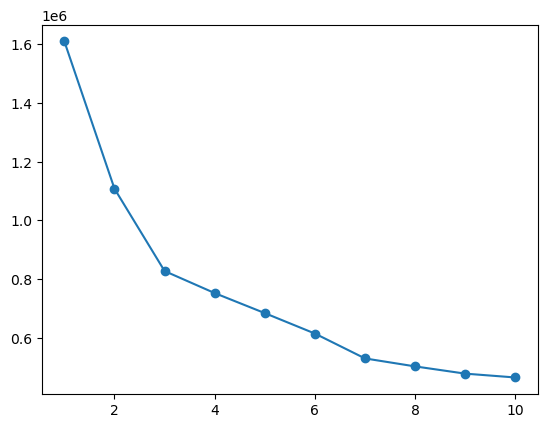

In [89]:
from sklearn.cluster import KMeans
sse=[]
k_range=range(1,11)
for i in k_range:
    km=KMeans(n_clusters=i, random_state=42, n_init='auto')
    km.fit(X_scaled)
    sse.append(km.inertia_)
plt.plot(k_range, sse, marker='o')
plt.show()

### Baseline model

In [90]:
km=KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = km.fit_predict(X_scaled)

#### Add cluster labels

In [91]:
user_df2['Cluster']=labels

In [92]:
user_df2.head()

,user_id,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand,purchase_rate,cart_rate,cart_to_purchase_ratio,Cluster
0,104655840,0.0,0.0,0.693147,0.693147,1,2.389680,0.693147,0.693147,0.0,0.0,0.0,2
1,128968633,0.0,0.0,2.944439,2.944439,1,5.279777,1.386294,1.791759,0.0,0.0,0.0,0
2,176250879,0.0,0.0,1.386294,1.386294,1,6.044531,0.693147,0.693147,0.0,0.0,0.0,2
3,178539771,0.0,0.0,0.693147,0.693147,1,6.340835,0.693147,0.693147,0.0,0.0,0.0,2
4,208005640,0.0,0.0,1.609438,1.609438,1,5.642111,0.693147,1.386294,0.0,0.0,0.0,2


#### Validating the model using silhouette

In [93]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)

np.float64(0.39149305191769807)

#### Scatter plot

In [94]:
#redcuing the dimensinons usIng PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

In [95]:
#gives linear combinations of all features
pca.components_

array([[ 0.39700476,  0.40427707,  0.30499074,  0.36425849,  0.21120366,
         0.01197594,  0.17284081,  0.22228217,  0.32967903,  0.30178069,
         0.35979177],
       [-0.15213662, -0.24049768,  0.41326466,  0.3419238 ,  0.15715357,
         0.016714  ,  0.3755234 ,  0.45126564, -0.33505076, -0.26781361,
        -0.27874273]])

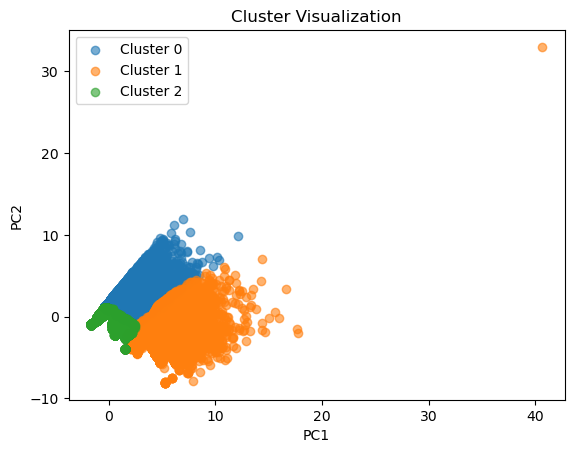

In [96]:
for i in range(3):
    plt.scatter(
        X_pca[labels == i, 0],
        X_pca[labels == i, 1],
        label=f'Cluster {i}',
        alpha=0.6
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cluster Visualization')
plt.legend()
plt.show()

Not a very good distinction between groups as observed from silhouette score

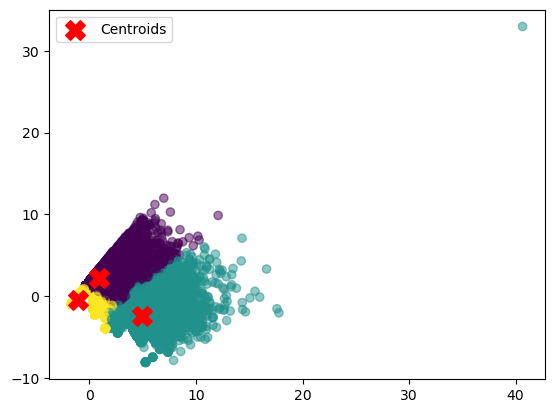

In [97]:
# plot points
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, alpha=0.5)

# plot centroids
centers_pca = pca.transform(km.cluster_centers_)

plt.scatter(
    centers_pca[:,0],
    centers_pca[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.legend()
plt.show()

- Centroids are relatively close → moderate separation
- one centroid is away while other two very close -> forced clustering


In [98]:
user_df2.groupby('Cluster').mean()

,user_id,total_cart,total_purchase,total_view,total_events,total_session,avg_price,unique_category,unique_brand,purchase_rate,cart_rate,cart_to_purchase_ratio
Cluster,,,,,,,,,,,,
0,5.730822e+08,0.176271,0.006281,2.540349,2.562437,1.536659,5.248396,1.126979,1.593778,0.000201,0.021675,0.003679
1,5.784542e+08,1.140626,0.804545,1.966698,2.405233,1.747399,5.228315,0.843057,1.052926,0.151311,0.239151,0.705480
2,5.800988e+08,0.048362,0.000043,1.105358,1.123224,1.063781,5.162955,0.728705,0.800962,0.000010,0.019750,0.000000


Overlapping clusters hence we will check once with other models and it's efficiencies

#### Observation
**Cluster 0** 
- total_view & total_events = highest
- total_purchase ≈ 0
- purchase_rate ≈ 0
- Users browse a lot but don’t convert
- Slightly higher diversity so explorers
- **Window shoppers / browsers** 
- **Business** :Retargeting, discounts, UX improvements 

**Cluster 1**
- total_purchase = 0.80 (highest)
- purchase_rate = 0.15 (very high vs others ~0.0002)
- cart_rate = 0.23 (highest)
- Users actively move through funnel and convert
- Lower unique_category, unique_brand
- Focused buyers (not exploratory)
- **High-intent buyers / converters** 
- **Business**: Target with loyalty, upsell, premium offers 

**Cluster 2**
- lowest views, events, carts, purchases
- purchase_rate ≈ 0
- Users barely engage
- **Low-engagement / inactive users** 
- **Business**: Reactivation campaigns or ignore (low ROI)

### Dbscan

In [99]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=0.5, min_samples=5)
db_labels=db.fit_predict(X_scaled)

In [100]:
silhouette_score(X_scaled, db_labels, sample_size=10000, random_state=42)

np.float64(0.08993021891912042)

#### Observation
KMeans silhouette ≈ 0.39
DBSCAN silhouette ≈ 0.089
KMeans outperformed DBSCAN due to lack of clear density separation.
Clusters are behavior-driven and interpretable → suitable for business use
Final Model is KMeans

### Saving model in pickle file

In [102]:
import pickle

pickle.dump(km, open('km_model.pkl','wb'))
pickle.dump(scaler, open('scaler.pkl','wb'))